## READ ME!
Due to some versioning issues in the packages required vs. what is installed by default on this Google colab instance, this notebook will need to be restarted after running this first cell! You will be prompted to do so.

In [1]:
# Install hermpy package and clone repo
!pip install git+https://github.com/daraghhollman/hermpy-pre-0.1

!git clone https://github.com/daraghhollman/messenger_region_classifier
%cd /content/messenger_region_classifier

  Cloning https://github.com/daraghhollman/hermpy-pre-0.1 to /tmp/pip-req-build-mbv72j20
  Running command git clone --filter=blob:none --quiet https://github.com/daraghhollman/hermpy-pre-0.1 /tmp/pip-req-build-mbv72j20
  Resolved https://github.com/daraghhollman/hermpy-pre-0.1 to commit cf90549980c5cdddb8cad453c6aafb0c13233eae
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
fatal: destination path 'messenger_region_classifier' already exists and is not an empty directory.
/content/messenger_region_classifier


Let's start by downloading a small portion of data. NASA's PDS-PPI node for MESSENGER stores 1-second averaged data in daily files, so we will just download one of these for comarison.

In [2]:
import datetime as dt
import os
import pathlib
import requests
import sys

# This relies on an older version of hermpy: see pyproject.toml for more details.
import hermpy.utils
import hermpy.mag
import hermpy.plotting
import matplotlib.dates
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# 1st September 2011
url = "https://pds-ppi.igpp.ucla.edu/data/mess-mag-calibrated/data/mso-avg/2011/244_273_SEP/MAGMSOSCIAVG11244_01_V08.TAB"

save_dir = "./data/tmp/"
filename = os.path.basename(url)
save_path = os.path.join(save_dir, filename)
os.makedirs(save_dir, exist_ok=True)

# Check if we've downloaded the file already:
if not os.path.exists(save_path):
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(save_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

print(f"Data saved to: {save_path}")

Data saved to: ./data/tmp/MAGMSOSCIAVG11244_01_V08.TAB


Lastly, lets download the raw model output from Zenodo. This file is large, ~1.5 GB

In [4]:
url = "https://zenodo.org/records/17814795/files/raw_model_output.csv?download=1"
save_dir = "./data/tmp/"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "raw_model_output.csv")

if not os.path.exists(save_path):
    !wget -O "{save_path}" "{url}"

print("Saved to:", save_path)

--2026-05-29 10:22:37--  https://zenodo.org/records/17814795/files/raw_model_output.csv?download=1
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 188.184.103.118, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1414143959 (1.3G) [text/plain]
Saving to: ‘./data/tmp/raw_model_output.csv’

./data/tmp/raw_mode 100%[===================>]   1.32G  2.77MB/s    in 4m 41s  

2026-05-29 10:27:18 (4.80 MB/s) - ‘./data/tmp/raw_model_output.csv’ saved [1414143959/1414143959]

Saved to: ./data/tmp/raw_model_output.csv


We need to tell the hermpy package where to expect our data files:

In [5]:
hermpy.utils.User.DATA_DIRECTORIES["MAG"] = "./data/tmp/"

That's all of the set up out of the way, we can now load our data and compare with the raw model output.

Let's first take a look at the data itself:

In [6]:
# Define a time range to look at
start_time = dt.datetime(2011, 9, 1, 9)
end_time = dt.datetime(2011, 9, 1, 11)

# Load the MAG data into memory
data = hermpy.mag.Load_Between_Dates(
    hermpy.utils.User.DATA_DIRECTORIES["MAG"],
    start_time,
    end_time,
    aberrate=False,
    no_dirs=True # Here we tell hermpy to expect data files in one directory, rather than the directory structure they exist in on the pds
)

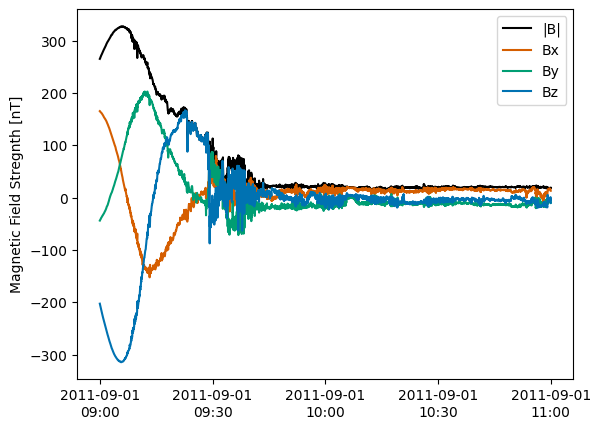

In [7]:
# Lets visualise this time range
fig, ax = plt.subplots()

to_plot = ["|B|", "Bx", "By", "Bz"]
colours = [hermpy.plotting.wong_colours[c] for c in ["black", "red", "green", "blue"]]

for var, colour in zip(to_plot, colours):
    ax.plot(data["date"], data[var], color=colour, label=var)

ax.legend()
ax.xaxis.set_major_locator(matplotlib.dates.MinuteLocator([0, 30]))
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.set_ylabel("Magnetic Field Stregnth [nT]");

Lets draw the model output alongside this. To do this, we will first filter the model output to just the times we need.

In [8]:
# Import as pandas dataframe
model_output = pd.read_csv("./data/tmp/raw_model_output.csv")
model_output["Time"] = pd.to_datetime(model_output["Time"], format="ISO8601")
model_output = model_output.loc[(model_output["Time"] > start_time) & (model_output["Time"] < end_time)]

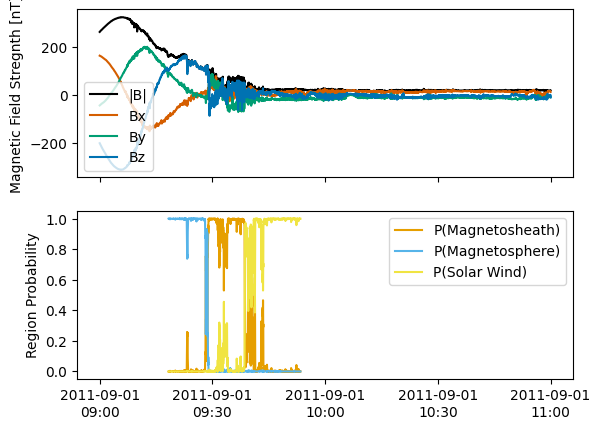

In [9]:
fig, axes = plt.subplots(2, 1, sharex=True)
mag_ax, proba_ax = axes

to_plot = ["|B|", "Bx", "By", "Bz"]
mag_colours = [hermpy.plotting.wong_colours[c] for c in ["black", "red", "green", "blue"]]

for var, colour in zip(to_plot, mag_colours):
    mag_ax.plot(data["date"], data[var], color=colour, label=var)

mag_ax.legend()
mag_ax.set_ylabel("Magnetic Field Stregnth [nT]")

labels = ["P(Magnetosheath)", "P(Magnetosphere)", "P(Solar Wind)"]
region_colours = [hermpy.plotting.wong_colours[c] for c in ["orange", "light blue", "yellow"]]

for colour, label in zip(region_colours, labels):
    proba_ax.plot(model_output["Time"], model_output[label], color=colour, label=label)

proba_ax.legend()
proba_ax.xaxis.set_major_locator(matplotlib.dates.MinuteLocator([0, 30]))
proba_ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y-%m-%d\n%H:%M"))
proba_ax.set_ylabel("Region Probability");